In [1]:
!python --version
!which python

Python 3.12.4
/public/workspace/ryrl/venvs/versions/3.12.4/torch/bin/python


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('google-bert/bert-base-cased')
tokenizer

/public/workspace/ryrl/venvs/versions/3.12.4/torch/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


BertTokenizerFast(name_or_path='google-bert/bert-base-cased', vocab_size=28996, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [3]:
encoded = tokenizer('Do not meddle in the affairs of wizards, for they are subtle and quick to anger.')
encoded

{'input_ids': [101, 2091, 1136, 1143, 13002, 1107, 1103, 5707, 1104, 16678, 1116, 117, 1111, 1152, 1132, 11515, 1105, 3613, 1106, 4470, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [4]:
len(encoded['input_ids'])

22

In [4]:
tokenizer.decode(encoded['input_ids'])

2025-01-30 20:43:20.817312: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-30 20:43:21.214488: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-30 20:43:21.292099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-30 20:43:21.452026: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-30 20:43:21.474663: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-30 20:43:21.675843: I tensorflow/core/platform/cpu_feature_gu

'[CLS] Do not meddle in the affairs of wizards, for they are subtle and quick to anger. [SEP]'

In [5]:
batch_sentences = [
    "But what about second breakfast?",
    "Don't think he knows about second breakfast, Pip.",
    "What about elevensies?",
]

encoded_inputs = tokenizer(batch_sentences)
encoded_inputs

{'input_ids': [[101, 1252, 1184, 1164, 1248, 6462, 136, 102], [101, 1790, 112, 189, 1341, 1119, 3520, 1164, 1248, 6462, 117, 21902, 1643, 119, 102], [101, 1327, 1164, 5450, 23434, 136, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1]]}

In [6]:
len(encoded_inputs['input_ids'][0]), len(encoded_inputs['input_ids'][1]), len(encoded_inputs['input_ids'][2])

(8, 15, 7)

## Pad

In [9]:
encoded_inputs = tokenizer(batch_sentences, padding=True)
len(encoded_inputs['input_ids'][0]), len(encoded_inputs['input_ids'][1]), len(encoded_inputs['input_ids'][2])

(15, 15, 15)

In [10]:
encoded_inputs = tokenizer(batch_sentences, padding=True, truncation=True)
len(encoded_inputs['input_ids'][0]), len(encoded_inputs['input_ids'][1]), len(encoded_inputs['input_ids'][2])

(15, 15, 15)

## Truncation

In [12]:
from datasets import load_dataset, Audio

In [20]:
dataset = load_dataset('PolyAI/minds14', name='en-US', split='train', force_download=True)
len(dataset)

HfHubHTTPError: 416 Client Error: Requested Range Not Satisfiable for url: https://hf-mirror.com/datasets/PolyAI/minds14/resolve/75900a7c6f93f014f25b50d16596a6da89add3a5/minds14.py (Request ID: Root=1-679b7a92-6afb304079c3afea4b43dc11;4c7a06fe-dea3-4686-a9b6-447f939ef463)

## Computer vision

In [22]:
dataset = load_dataset("food101", split="train[:10]")

train-00004-of-00008.parquet:  49%|####8     | 231M/475M [00:00<?, ?B/s]

train-00005-of-00008.parquet:   0%|          | 0.00/470M [00:00<?, ?B/s]

train-00006-of-00008.parquet:   0%|          | 0.00/478M [00:00<?, ?B/s]

train-00007-of-00008.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

validation-00000-of-00003.parquet:   0%|          | 0.00/423M [00:00<?, ?B/s]

validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

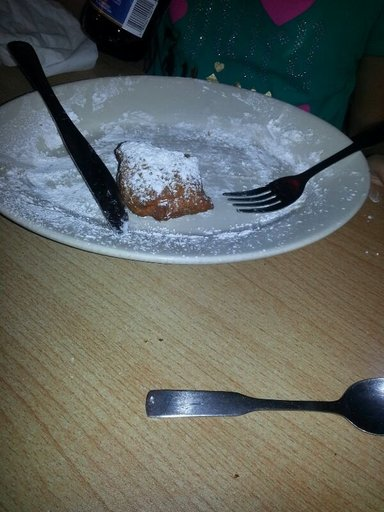

In [24]:
dataset[0]['image']

In [25]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [26]:
from torchvision.transforms import RandomResizedCrop, ColorJitter, Compose

size = (
    image_processor.size['shortest)edge'] if 'shortest_edge' in image_processor.size
    else (image_processor.size['height'], image_processor.size['width'])
)
size

(224, 224)

In [27]:
_transformers = Compose([RandomResizedCrop(size), ColorJitter(brightness=.5, hue=.5)])
_transformers

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    ColorJitter(brightness=(0.5, 1.5), contrast=None, saturation=None, hue=(-0.5, 0.5))
)

In [31]:
def transforms(examples):
    images = [_transformers(img.convert("RGB")) for img in examples["image"]]
    examples["pixel_values"] = image_processor(images, do_resize=False, return_tensors="pt")["pixel_values"]
    return examples

In [32]:
dataset.set_transform(transforms)

In [34]:
dataset[0].keys()

dict_keys(['image', 'label', 'pixel_values'])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


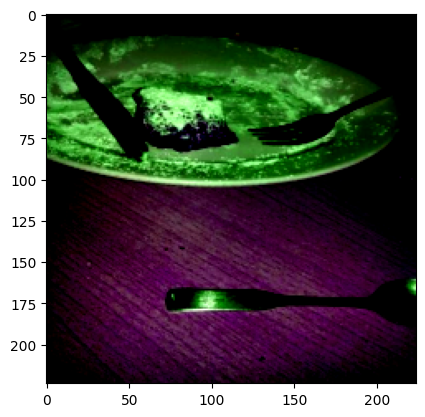

In [35]:
import numpy as np
import matplotlib.pyplot as plt

img = dataset[0]["pixel_values"]
plt.imshow(img.permute(1, 2, 0))

In [36]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels
    return batch

## Multimodel

In [38]:
from datasets import load_dataset

lj_speech = load_dataset("lj_speech", split="train")

ConnectionError: Couldn't reach 'lj_speech' on the Hub (LocalEntryNotFoundError)

In [39]:
from datasets import load_dataset

dataset = load_dataset("yelp_review_full")
dataset["train"][100]

ConnectionError: Couldn't reach 'yelp_review_full' on the Hub (LocalEntryNotFoundError)